# Deteccion de Tumores (Benigno vs Maligno) con Red Neuronal - Dataset sklearn

## Paso 1: Importar librerias

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

print(f"TensorFlow: {tf.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

TensorFlow: 2.21.0
Pandas: 3.0.1
NumPy: 2.4.3


## Paso 2: Cargar y validar dataset desde sklearn

In [11]:
breast = load_breast_cancer()

X_df = pd.DataFrame(breast.data, columns=breast.feature_names)
y_original = pd.Series(breast.target, name='target_original')

# En sklearn: 0=malignant, 1=benign. Lo invertimos para mantener: 0=Benigno, 1=Maligno
y = 1 - y_original

df = X_df.copy()
df['target'] = y.astype(int)
df['diagnosis'] = df['target'].map({0: 'B', 1: 'M'})

feature_cols = [c for c in df.columns if c not in ['diagnosis', 'target']]

if df['target'].isna().any():
    raise ValueError('Se detectaron valores nulos en target')

print('Dataset sklearn cargado correctamente')
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Features usadas: {len(feature_cols)}")
print('Mapeo target: 0=Benigno, 1=Maligno')

df.head()

Dataset sklearn cargado correctamente
Filas: 569
Columnas: 32
Features usadas: 30
Mapeo target: 0=Benigno, 1=Maligno


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,M


## Paso 3: Analisis exploratorio rapido

Valores nulos totales: 0
Benigno (0): 357
Maligno (1): 212


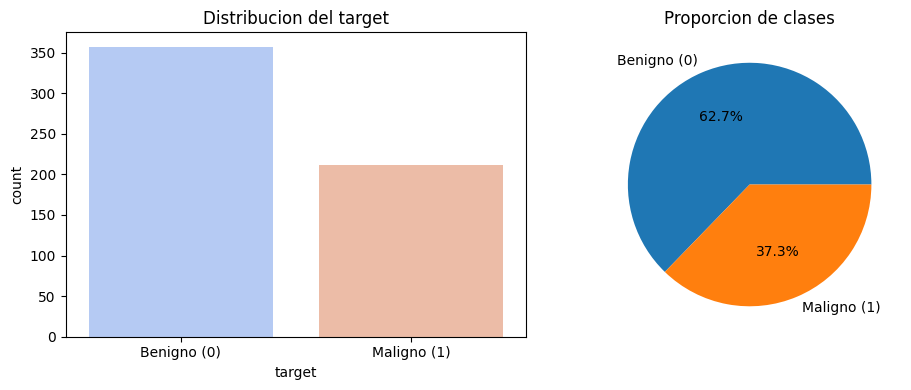

In [12]:
print('Valores nulos totales:', df.isnull().sum().sum())

conteo = df['target'].value_counts().sort_index()
print(f"Benigno (0): {conteo.get(0, 0)}")
print(f"Maligno (1): {conteo.get(1, 0)}")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.countplot(x='target', data=df, hue='target', palette='coolwarm', legend=False)
plt.title('Distribucion del target')
plt.xticks([0, 1], ['Benigno (0)', 'Maligno (1)'])

plt.subplot(1, 2, 2)
df['target'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%', labels=['Benigno (0)', 'Maligno (1)'])
plt.ylabel('')
plt.title('Proporcion de clases')

plt.tight_layout()
plt.show()

## Paso 4: Preprocesamiento (train/val/test estratificado)

In [13]:
X = df[feature_cols].copy()
y = df['target'].copy()

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

print('Escalado completado')
print(f"Media train escalado: {X_train_scaled.mean():.4f}")
print(f"Std train escalado: {X_train_scaled.std():.4f}")

Train: (364, 30), Validation: (91, 30), Test: (114, 30)
Escalado completado
Media train escalado: 0.0000
Std train escalado: 1.0000


## Paso 5: Crear y entrenar la red neuronal

In [14]:
num_features = X_train_scaled.shape[1]

model = Sequential([
    Input(shape=(num_features,)),
    Dense(64, activation='relu'),
    Dropout(0.30),
    Dense(32, activation='relu'),
    Dropout(0.20),
    Dense(16, activation='relu'),
    Dropout(0.10),
    Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

print('Entrenamiento finalizado')
print(f"Epochs ejecutados: {len(history.history['loss'])}")

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.7033 - loss: 0.5991 - val_accuracy: 0.9121 - val_loss: 0.4844
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8709 - loss: 0.4471 - val_accuracy: 0.9560 - val_loss: 0.3383
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9286 - loss: 0.3275 - val_accuracy: 0.9560 - val_loss: 0.2275
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9258 - loss: 0.2452 - val_accuracy: 0.9560 - val_loss: 0.1632
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9478 - loss: 0.1766 - val_accuracy: 0.9560 - val_loss: 0.1320
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9478 - loss: 0.1392 - val_accuracy: 0.9670 - val_loss: 0.1159
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9615 - loss: 0.1208 - val_accuracy: 0.9670 - val_loss: 0.1073
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9588 - loss: 0.1114 - val_accuracy: 0.

## Paso 6: Evaluacion del modelo

In [15]:
y_pred_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print('\nReporte de clasificacion:')
print(classification_report(y_test, y_pred, target_names=['Benigno (0)', 'Maligno (1)']))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Accuracy:  0.9825
Precision: 1.0000
Recall:    0.9524
F1-score:  0.9756
ROC-AUC:   0.9950

Reporte de clasificacion:
              precision    recall  f1-score   support

 Benigno (0)       0.97      1.00      0.99        72
 Maligno (1)       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



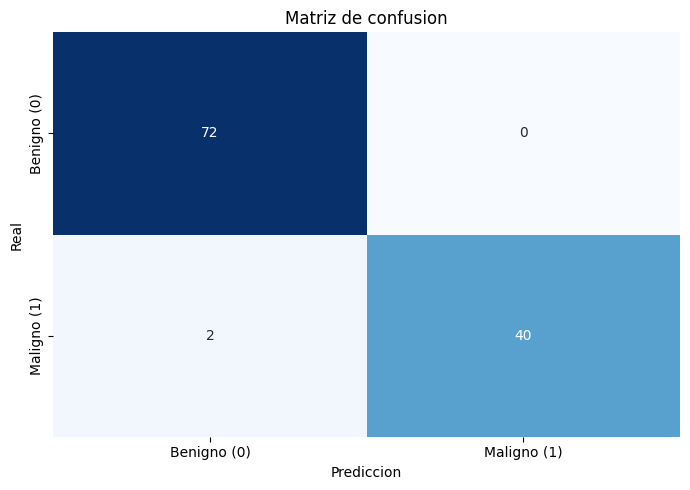

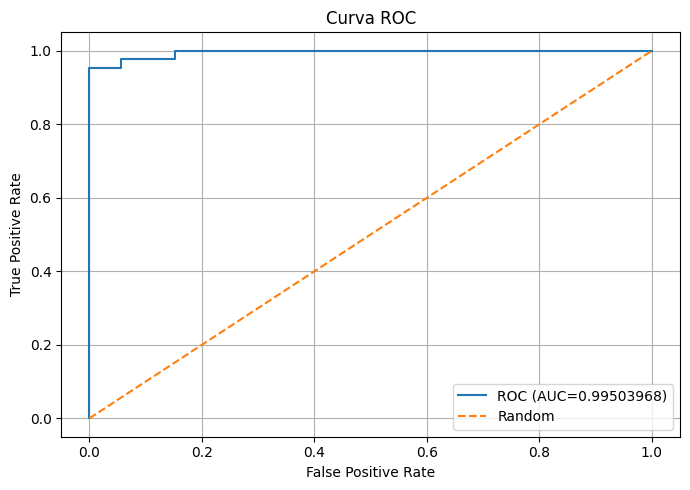

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de confusion')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.xticks([0.5, 1.5], ['Benigno (0)', 'Maligno (1)'])
plt.yticks([0.5, 1.5], ['Benigno (0)', 'Maligno (1)'])
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC (AUC={roc_auc:.8f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Paso 7: Prediccion para nuevos parametros

In [17]:
TARGET_MAP = {0: 'Benigno', 1: 'Maligno'}

def predecir_tumor(parametros_entrada, modelo, escalador, columnas_modelo, umbral=0.5):
    faltantes = [c for c in columnas_modelo if c not in parametros_entrada]
    if faltantes:
        raise ValueError(f'Faltan parametros: {faltantes}')

    x_df = pd.DataFrame([parametros_entrada], columns=columnas_modelo)
    x_scaled = escalador.transform(x_df)

    prob_maligno = float(modelo.predict(x_scaled, verbose=0).flatten()[0])
    prob_benigno = 1.0 - prob_maligno
    pred = 1 if prob_maligno >= umbral else 0

    return {
        'prob_maligno': prob_maligno,
        'prob_benigno': prob_benigno,
        'pred_clase': pred,
        'pred_etiqueta': TARGET_MAP[pred],
    }

# Ejemplo de uso con los promedios del dataset
PARAMETROS_USUARIO = X.mean().to_dict()

resultado = predecir_tumor(
    PARAMETROS_USUARIO,
    modelo=model,
    escalador=scaler,
    columnas_modelo=feature_cols,
    umbral=0.5,
)

print('=== Resultado de prediccion ===')
print(f"Prob. maligno: {resultado['prob_maligno']:.4f}")
print(f"Prob. benigno: {resultado['prob_benigno']:.4f}")
print(f"Clase predicha: {resultado['pred_clase']} -> {resultado['pred_etiqueta']}")

=== Resultado de prediccion ===
Prob. maligno: 0.2576
Prob. benigno: 0.7424
Clase predicha: 0 -> Benigno


In [18]:
# Diagnostico rapido de por que el modelo aprende
corr_abs = df[feature_cols + ['target']].corr(numeric_only=True)['target'].drop('target').abs().sort_values(ascending=False)

print('Top 10 correlaciones absolutas con target:')
print(corr_abs.head(10))
print(f'\nCorrelacion maxima abs: {corr_abs.max():.4f}')
print(f'Correlacion media abs: {corr_abs.mean():.4f}')

print('\nDistribucion de clases en dataset completo:')
print(df['target'].value_counts(normalize=True).sort_index())

print('\nValores minimos por feature (primeras 10):')
print(df[feature_cols].min().head(10))

Top 10 correlaciones absolutas con target:
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
Name: target, dtype: float64

Correlacion maxima abs: 0.7936
Correlacion media abs: 0.4703

Distribucion de clases en dataset completo:
target
0    0.627417
1    0.372583
Name: proportion, dtype: float64

Valores minimos por feature (primeras 10):
mean radius                 6.98100
mean texture                9.71000
mean perimeter             43.79000
mean area                 143.50000
mean smoothness             0.05263
mean compactness            0.01938
mean concavity              0.00000
mean concave points         0.00000
mean symmetry               0.10600
mean fractal dimension      0.04996
dtype: float64
